# Introduction

This Notebook analyses countries GDP 2020-2025.

# Data analysis

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from pathlib import Path
import plotly.express as px

In [2]:
df = pd.read_csv("/kaggle/input/gdp-per-country-20202025/2020-2025.csv")

In [3]:
df.head()

/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1458: RuntimeWarning: invalid value encountered in greater
  has_large_values = (abs_vals > 1e6).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in less
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()
/usr/local/lib/python3.11/dist-packages/pandas/io/formats/format.py:1459: RuntimeWarning: invalid value encountered in greater
  has_small_values = ((abs_vals < 10 ** (-self.digits)) & (abs_vals > 0)).any()


,Country,2020,2021,2022,2023,2024,2025
0,Afghanistan,20136,14278.0,14501.0,17248.0,NaN,NaN
1,Albania,15271,18086.0,19185.0,23388.0,27259.0,28372.0
2,Algeria,164774,185850.0,225709.0,247789.0,264913.0,268885.0
3,Andorra,2885,3325.0,3376.0,3786.0,4038.0,4035.0
4,Angola,66521,84375.0,142442.0,109764.0,115946.0,113343.0


In [4]:
df.shape

(196, 7)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 7 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   Country  196 non-null    object 
 1   2020     196 non-null    int64  
 2   2021     194 non-null    float64
 3   2022     194 non-null    float64
 4   2023     194 non-null    float64
 5   2024     192 non-null    float64
 6   2025     189 non-null    float64
dtypes: float64(5), int64(1), object(1)
memory usage: 10.8+ KB


In some of the years (exception 2020) few countries miss values.

In [6]:
df.describe()

,2020,2021,2022,2023,2024,2025
count,1.960000e+02,1.940000e+02,1.940000e+02,1.940000e+02,1.920000e+02,1.890000e+02
mean,4.378886e+05,5.043504e+05,5.255064e+05,5.486173e+05,5.756871e+05,5.991414e+05
std,1.942936e+06,2.220864e+06,2.347886e+06,2.453040e+06,2.573189e+06,2.693421e+06
min,5.200000e+01,6.200000e+01,6.100000e+01,6.300000e+01,6.500000e+01,6.500000e+01
25%,9.588000e+03,1.114175e+04,1.265000e+04,1.360450e+04,1.350050e+04,1.421400e+04
50%,3.533450e+04,3.771900e+04,4.156800e+04,4.363100e+04,4.713550e+04,4.782900e+04
75%,2.074810e+05,2.546132e+05,2.746308e+05,2.850355e+05,2.915108e+05,3.032930e+05
max,2.135412e+07,2.368118e+07,2.600690e+07,2.772072e+07,2.918490e+07,3.050722e+07


In [7]:
df.Country.nunique()

196

Which country had the largest GDP in 2020?

In [8]:
df.sort_values(by="2020", ascending=False).head(1)

,Country,2020,2021,2022,2023,2024,2025
186,United States,21354125,23681175.0,26006900.0,27720725.0,29184900.0,30507217.0


Which country had the largest GDP in 2025?

In [9]:
df.sort_values(by="2025", ascending=False).head(1)

,Country,2020,2021,2022,2023,2024,2025
186,United States,21354125,23681175.0,26006900.0,27720725.0,29184900.0,30507217.0


Which country had the smallest GDP in 2020?

In [10]:
df.sort_values(by="2020", ascending=True).head(1)

,Country,2020,2021,2022,2023,2024,2025
181,Tuvalu,52,62.0,61.0,63.0,65.0,65.0


Which country had the smallest GDP in 2025?

In [11]:
df.sort_values(by="2025", ascending=True).head(1)

,Country,2020,2021,2022,2023,2024,2025
181,Tuvalu,52,62.0,61.0,63.0,65.0,65.0


Which countries had the largest procentual gain of GDP between 2020 and 2025 (top 10)?

In [12]:
df["2020-2025%"] = (df["2025"] - df["2020"]) / df["2020"]
df["2020-2025%"] = round(df["2020-2025%"], 2)
df.sort_values(by="2020-2025%", ascending=False).head(10)

,Country,2020,2021,2022,2023,2024,2025,2020-2025%
71,Guyana,5471,8041.0,14718.0,16919.0,24659.0,25822.0,3.72
190,Venezuela,42838,56615.0,89013.0,102377.0,119808.0,108511.0,1.53
93,Kyrgyzstan,8283,9256.0,12269.0,15187.0,17491.0,19849.0,1.40
72,Haiti,14508,21017.0,19826.0,19603.0,26229.0,33548.0,1.31
63,Georgia,16013,18849.0,24985.0,30778.0,33775.0,35353.0,1.21
28,Burundi,3089,3356.0,3922.0,4246.0,4743.0,6745.0,1.18
69,Guinea,14089,16320.0,19589.0,22750.0,25758.0,30094.0,1.14
102,Macau,25344,30969.0,24998.0,45802.0,50182.0,53354.0,1.11
7,Armenia,12642,13879.0,19514.0,24086.0,25533.0,26258.0,1.08
106,Maldives,3706,5242.0,6168.0,6581.0,7019.0,7480.0,1.02


Which countries had the sharpest drop of GDP (as percent) between 2020 and 2025?

In [13]:
df.sort_values(by="2020-2025%", ascending=True).head(10)

,Country,2020,2021,2022,2023,2024,2025,2020-2025%
127,Nigeria,432299,441074.0,476468.0,363816.0,187640.0,188271.0,-0.56
159,South Sudan,5423,5940.0,8037.0,7186.0,5423.0,3998.0,-0.26
85,Japan,5054069,5039148.0,4262146.0,4213167.0,4026211.0,4186431.0,-0.17
193,Yemen,20220,19394.0,23534.0,19412.0,19101.0,17401.0,-0.14
94,Laos,18511,18533.0,15121.0,14978.0,15879.0,16322.0,-0.12
165,Sudan,35237,35142.0,33517.0,36998.0,28270.0,31506.0,-0.11
51,Egypt,382525,423300.0,475231.0,393828.0,383109.0,347342.0,-0.09
174,Timor-Leste,2163,3625.0,3209.0,2080.0,2015.0,2115.0,-0.02
119,Myanmar,65631,58264.0,61723.0,61466.0,61176.0,64944.0,-0.01
99,Libya,46893,35216.0,43281.0,43958.0,42159.0,47484.0,0.01


# Data visualization

In [14]:
df.columns = [str(c) for c in df.columns]
year_cols = [c for c in df.columns if c != "Country"  and c!= "2020-2025%"]

# Coerce numeric, keep NaNs, then forward-fill per country across years
for c in year_cols:
    df[c] = pd.to_numeric(df[c], errors="coerce")

df[year_cols] = df[year_cols].ffill(axis=1)  # forward-fill across years per row
df[year_cols] = df[year_cols].bfill(axis=1)  # back-fill if leading NaNs

# Melt to long/tidy format
tidy = df.melt(id_vars="Country", value_vars=year_cols,
               var_name="Year", value_name="GDP")
tidy["Year"] = tidy["Year"].astype(int)
tidy = tidy.sort_values(["Year", "GDP"], ascending=[True, False]).reset_index(drop=True)

# Compute per-year rank (1 = largest GDP)
tidy["Rank"] = tidy.groupby("Year")["GDP"].rank(method="first", ascending=False)

In [15]:
def pick_countries(n=10, by_year=2025, min_gdp=None, include=None):
    """
    Pick a set of countries to plot lines for.
    - n: top-N by GDP in `by_year`
    - min_gdp: minimum GDP threshold in `by_year` (overrides n if used)
    - include: list of country names to always include
    """
    year_df = tidy[tidy["Year"] == by_year].dropna(subset=["GDP"])
    chosen = set()
    if min_gdp is not None:
        chosen.update(year_df[year_df["GDP"] >= min_gdp]["Country"].head(196).tolist())
    else:
        chosen.update(year_df.sort_values("GDP", ascending=False)["Country"].head(n).tolist())
    if include:
        chosen.update(include)
    return sorted(chosen)

In [16]:
def plot_lines(countries=None, start=2020, end=2025):
    data = tidy[(tidy["Year"]>=start) & (tidy["Year"]<=end)]
    if countries is None:
        countries = pick_countries(n=10, by_year=end)
    fig, ax = plt.subplots(figsize=(10,6))
    for c in countries:
        sub = data[data["Country"]==c].sort_values("Year")
        ax.plot(sub["Year"], sub["GDP"], label=c, linewidth=2)
        ax.scatter(sub["Year"], sub["GDP"])
    ax.set_title(f"GDP Evolution {start}-{end}")
    ax.set_xlabel("Year")
    ax.set_ylabel("GDP")
    ax.grid(True, alpha=0.3)
    ax.legend(loc="best", fontsize=8, ncol=2)
    plt.tight_layout()
    plt.show()

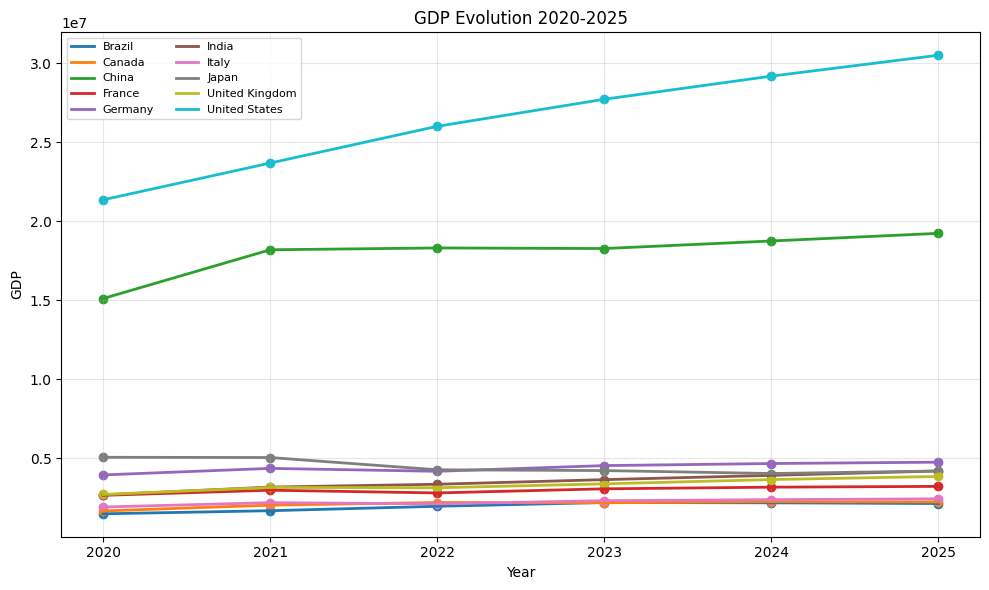

In [17]:
plot_lines()

In [18]:
def bar_chart_race(save_path="bar_chart_race.mp4", top_n=20, start=2020, end=2025, fps=2):
    years = list(range(start, end+1))
    frames = []
    for y in years:
        frame = tidy[tidy["Year"]==y].nlargest(top_n, "GDP").copy()
        frame = frame.sort_values("GDP", ascending=True)  # for horizontal bars rising up
        frames.append(frame)

    # Prepare figure
    fig, ax = plt.subplots(figsize=(10,7))
    bars = ax.barh(frames[0]["Country"], frames[0]["GDP"])
    ax.set_xlabel("GDP")
    ax.set_title(f"Top {top_n} GDP — {years[0]}")

    def update(i):
        frame = frames[i]
        ax.clear()
        ax.barh(frame["Country"], frame["GDP"])
        ax.set_xlabel("GDP")
        ax.set_title(f"Top {top_n} GDP — {years[i]}")
        ax.grid(True, axis="x", alpha=0.3)

    anim = FuncAnimation(fig, update, frames=len(years), interval=1000//fps, repeat=False)
    # Save to MP4 (requires ffmpeg) or comment out to just display
    try:
        anim.save(save_path, fps=fps, dpi=150)
        print(f"Saved: {Path(save_path).resolve()}")
    except Exception as e:
        print("Could not save video (is ffmpeg installed?). Showing inline instead.", e)
        plt.show()


Saved: /kaggle/working/bar_chart_race.mp4


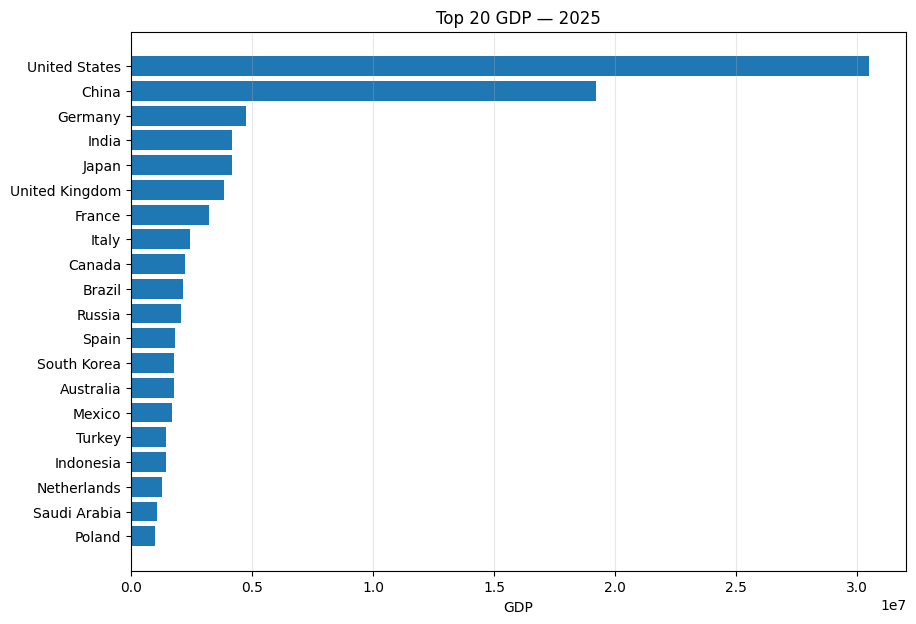

In [19]:
bar_chart_race()

In [20]:
def bubble_timeline(save_path="bubble_timeline.mp4", start=2020, end=2025, max_countries=25, fps=2):
    data = tidy[(tidy["Year"]>=start) & (tidy["Year"]<=end)].copy()
    years = sorted(data["Year"].unique())

    # Normalize sizes for bubbles
    gdp_min = data["GDP"].min()
    gdp_max = data["GDP"].max()
    # scale marker size (points^2). Adjust multiplier if bubbles look too small/large.
    def size_scale(x):
        if pd.isna(x):
            return 0.0
        return 50 + 950.0 * ((x - gdp_min) / (gdp_max - gdp_min + 1e-9))

    fig, ax = plt.subplots(figsize=(10,7))

    def update(i):
        ax.clear()
        year = years[i]
        frame = data[data["Year"]==year].nsmallest(max_countries, "Rank")
        sizes = frame["GDP"].apply(size_scale).to_numpy()
        ax.scatter(frame["Year"], frame["Rank"], s=sizes)
        # Annotate a few top countries
        top = frame.nsmallest(25, "Rank")
        for _, row in top.iterrows():
            ax.text(row["Year"]+ 0.1, row["Rank"], row["Country"], va="center", ha="left", fontsize=8)

        ax.set_xlim(start-0.5, end+0.75)
        ax.set_ylim(frame["Rank"].max()+2, -2)  # invert so Rank 1 is at the top
        ax.set_xlabel("Year")
        ax.set_ylabel("Rank (1 = highest GDP)")
        ax.set_title(f"GDP Bubble Timeline — {year}")
        ax.grid(True, alpha=0.3)
        
    anim = FuncAnimation(fig, update, frames=len(years), interval=1000//fps, repeat=False)
    try:
        anim.save(save_path, fps=fps, dpi=150)
        print(f"Saved: {Path(save_path).resolve()}")
    except Exception as e:
        print("Could not save video (is ffmpeg installed?). Showing inline instead.", e)
        plt.show()

Saved: /kaggle/working/bubble_timeline.mp4


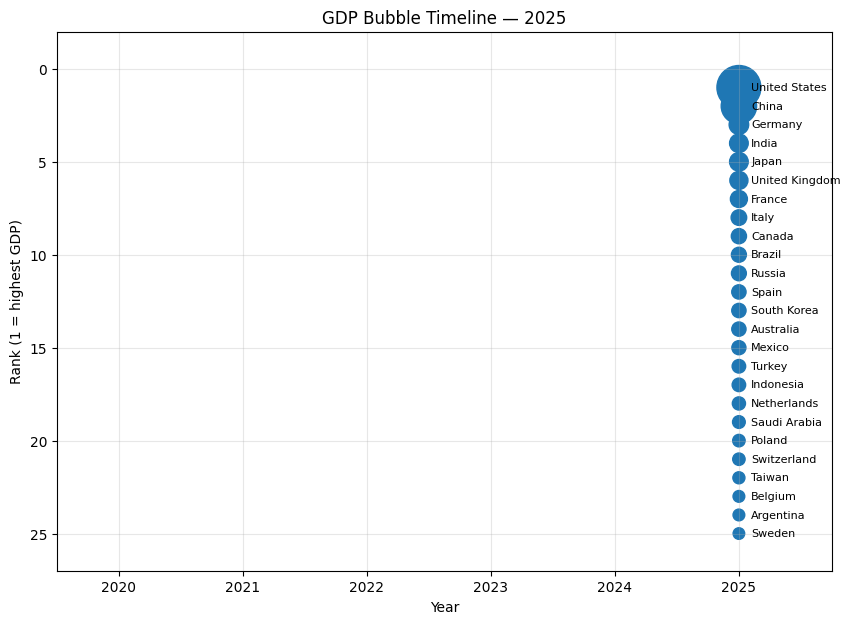

In [21]:
bubble_timeline()